**Estimate a probability of default model for credit card borrowers.**

In [ ]:
#https://drive.google.com/file/d/13_e5FSnvsOSVEtMNVnAQiVig-20QEdlW/view?usp=sharing
# install pydrive to load data
!pip install -U -q PyDrive

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id = "13_e5FSnvsOSVEtMNVnAQiVig-20QEdlW"
file = drive.CreateFile({'id':id})
file.GetContentFile('extra_credit_project_data.csv')

In [ ]:
import numpy as np
import pandas as pd

credit_card_df = pd.read_csv('extra_credit_project_data.csv')
credit_card_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Part 1: Data Exploration

## Part 1.1: Understand the Raw Dataset

In [ ]:
# check data info
credit_card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
# check the unique values for each column
credit_card_df.nunique()

,0
Unnamed: 0,150000
SeriousDlqin2yrs,2
RevolvingUtilizationOfUnsecuredLines,125728
age,86
NumberOfTime30-59DaysPastDueNotWorse,16
DebtRatio,114194
MonthlyIncome,13594
NumberOfOpenCreditLinesAndLoans,58
NumberOfTimes90DaysLate,19
NumberRealEstateLoansOrLines,28


In [ ]:
# Get target variable
y = credit_card_df['SeriousDlqin2yrs']

## Part 1.2: Understand the features

In [ ]:
# check missing values
credit_card_df.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [ ]:
# understand Numerical feature
# discrete/continuous
# 'RevolvingUtilizationOfUnsecuredLines': Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits
# 'age': Age of borrower in years
# 'NumberOfTime30-59DaysPastDueNotWorse': Number of times borrower has been 30-59 days past due but no worse in the last 2 years.
# 'DebtRatio': Monthly debt payments, alimony,living costs divided by monthy gross income
# 'MonthlyIncome': Monthly income
# 'NumberOfOpenCreditLinesAndLoans': Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)
# 'NumberOfTimes90DaysLate': Number of times borrower has been 90 days or more past due.
# 'NumberRealEstateLoansOrLines': Number of mortgage and real estate loans including home equity lines of credit
# 'NumberOfTime60-89DaysPastDueNotWorse': Number of times borrower has been 60-89 days past due but no worse in the last 2 years.
# 'NumberOfDependents': Number of dependents in family excluding themselves (spouse, children etc.)
credit_card_df[['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']].describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
# check the feature distribution
# pandas.DataFrame.describe()
# boxplot, distplot, countplot
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfDependents'>

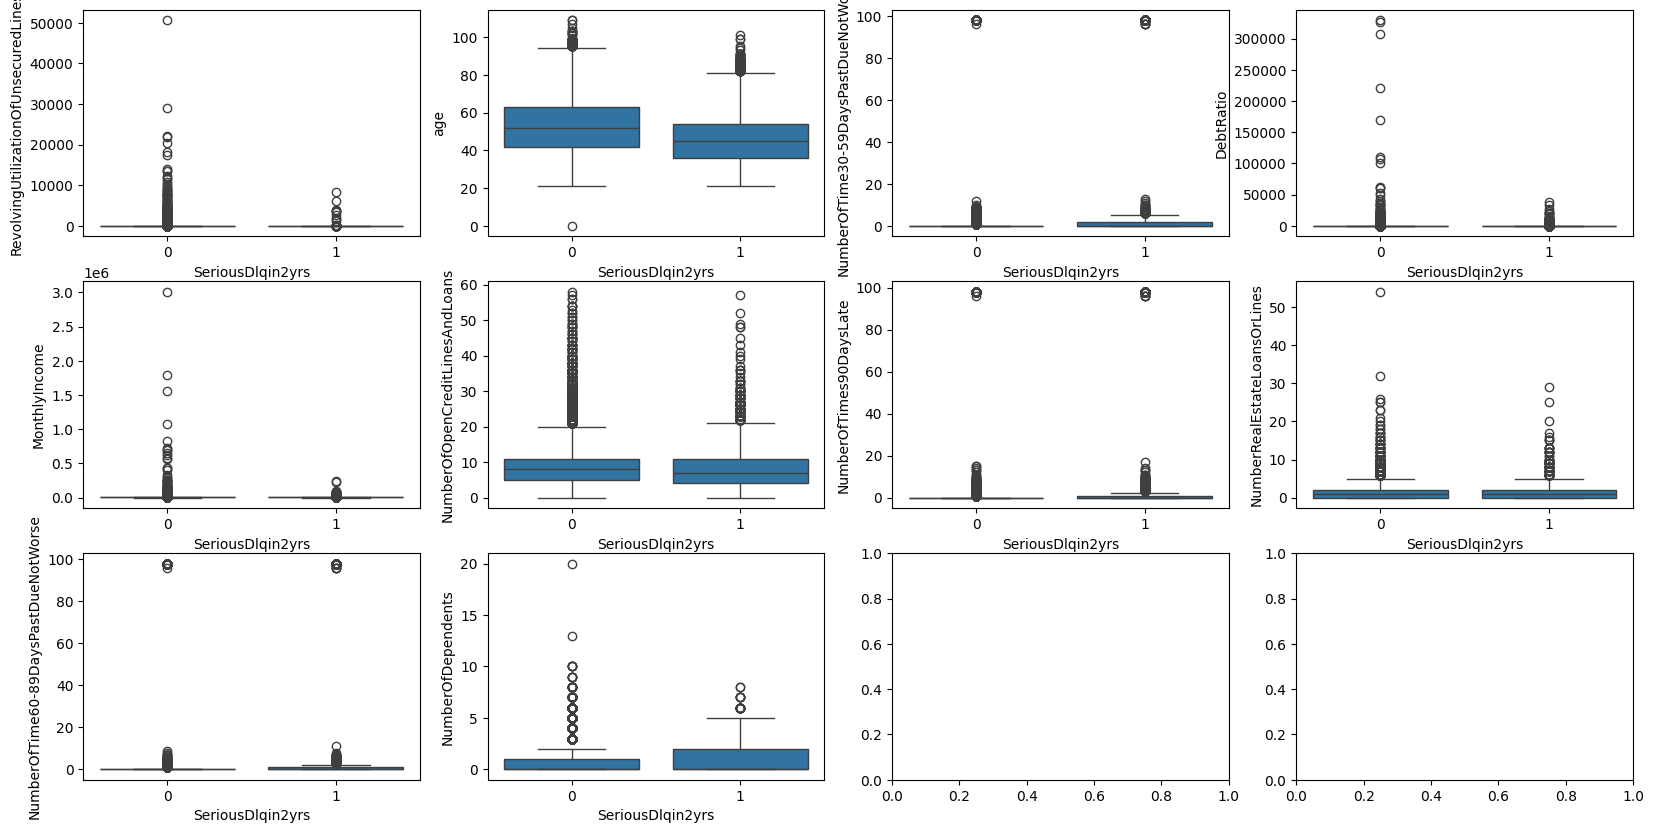

In [ ]:
# boxplot for numerical feature
_,axss = plt.subplots(3,4, figsize=[20,10])
sns.boxplot(x='SeriousDlqin2yrs', y ='RevolvingUtilizationOfUnsecuredLines', data=credit_card_df, ax=axss[0][0])
sns.boxplot(x='SeriousDlqin2yrs', y ='age', data=credit_card_df, ax=axss[0][1])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberOfTime30-59DaysPastDueNotWorse', data=credit_card_df, ax=axss[0][2])
sns.boxplot(x='SeriousDlqin2yrs', y ='DebtRatio', data=credit_card_df, ax=axss[0][3])
sns.boxplot(x='SeriousDlqin2yrs', y ='MonthlyIncome', data=credit_card_df, ax=axss[1][0])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberOfOpenCreditLinesAndLoans', data=credit_card_df, ax=axss[1][1])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberOfTimes90DaysLate', data=credit_card_df, ax=axss[1][2])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberRealEstateLoansOrLines', data=credit_card_df, ax=axss[1][3])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberOfTime60-89DaysPastDueNotWorse', data=credit_card_df, ax=axss[2][0])
sns.boxplot(x='SeriousDlqin2yrs', y ='NumberOfDependents', data=credit_card_df, ax=axss[2][1])

In [ ]:
# understand categorical feature

# Part 2: Feature Preprocessing

In [ ]:
# Get feature space by dropping useless feature
to_drop = ['Unnamed: 0','SeriousDlqin2yrs']
X = credit_card_df.drop(to_drop, axis = 1)

In [ ]:
X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
X.dtypes

,0
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64
NumberOfTime60-89DaysPastDueNotWorse,int64
NumberOfDependents,float64


In [ ]:
cat_cols = X.columns[X.dtypes == 'object'] #null
num_cols = X.columns[(X.dtypes == 'float64') | (X.dtypes == 'int64')]

In [ ]:
num_cols

Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [ ]:
cat_cols

Index([], dtype='object')

In [ ]:
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    lower = series.quantile(lower_percentile)
    upper = series.quantile(upper_percentile)
    return series.clip(lower=lower, upper=upper)

In [ ]:
X['MonthlyIncome'] = X['MonthlyIncome'].fillna(X['MonthlyIncome'].median()) #median
X['NumberOfDependents'] = X['NumberOfDependents'].fillna(X['NumberOfDependents'].median()) #median

X['RevolvingUtilizationOfUnsecuredLines'] = winsorize_series(X['RevolvingUtilizationOfUnsecuredLines'], 0.01, 0.99)
X['DebtRatio'] = winsorize_series(X['DebtRatio'], 0.01, 0.99)
X['NumberOfTime30-59DaysPastDueNotWorse'] = X['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=10)
X['NumberOfTime60-89DaysPastDueNotWorse'] = X['NumberOfTime60-89DaysPastDueNotWorse'].clip(upper=10)
X['NumberOfTimes90DaysLate'] = X['NumberOfTimes90DaysLate'].clip(upper=10)
X['NumberRealEstateLoansOrLines'] = X['NumberRealEstateLoansOrLines'].clip(upper=5)

X = X[X['age'] >= 18] # remove teen

In [ ]:
X.isnull().sum()

,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0
NumberOfDependents,0


In [ ]:
X.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.000000,149999.000000,149999.000000,149999.000000,1.499990e+05,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000
mean,0.320491,52.295555,0.263228,316.550977,6.418458e+03,8.452776,0.107921,1.002473,0.082634,0.737405
std,0.352149,14.771298,0.809436,906.964878,1.289044e+04,5.145964,0.635483,1.020301,0.534149,1.107020
min,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154176,52.000000,0.000000,0.366503,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559044,63.000000,0.000000,0.868257,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.092956,109.000000,10.000000,4979.040000,3.008750e+06,58.000000,10.000000,5.000000,10.000000,20.000000


In [ ]:
y = y.loc[X.index]

Split dataset

In [ ]:
# Splite data into training and testing
# 100 -> 75:y=1, 25:y=0
# training(80): 60 y=1; 20 y=0
# testing(20):  15 y=1; 5 y=0

from sklearn import model_selection

# Reserve 25% for testing
# stratify example:
# 100 -> y: 80 '0', 20 '1' -> 4:1
# 80% training 64: '0', 16:'1' -> 4:1
# 20% testing  16:'0', 4: '1' -> 4:1
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify = y, random_state = 1) #stratified sampling

print('training data has ' + str(X_train.shape[0]) + ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + ' observation with ' + str(X_test.shape[1]) + ' features')

training data has 112499 observation with 10 features
test data has 37500 observation with 10 features


In [ ]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
36165,0.593827,46,0,0.293338,9200.0,15,0,0,0,1.0
16122,0.057337,28,0,0.138246,3500.0,6,0,0,0,0.0
52616,0.002836,67,0,0.226702,7167.0,6,0,1,0,0.0
71444,0.694310,61,0,0.608030,6400.0,13,0,1,0,0.0
81371,1.000000,25,0,0.154211,4000.0,3,0,0,0,0.0


In [ ]:
# Scale the data, using standardization
# standardization (x-mean)/std
# normalization (x-x_min)/(x_max-x_min) ->[0,1]

# 1. speed up gradient descent
# 2. same scale
# 3. algorithm requirments

# for example, use training data to train the standardscaler to get mean and std
# apply mean and std to both training and testing data.
# fit_transform does the training and applying, transform only does applying.
# Because we can't use any info from test, and we need to do the same modification
# to testing data as well as training data

# https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py
# https://scikit-learn.org/stable/modules/preprocessing.html

# min-max example: (x-x_min)/(x_max-x_min)
# [1,2,3,4,5,6,100] -> fit(min:1, max:6) (scalar.min = 1, scalar.max = 6) -> transform [(1-1)/(6-1),(2-1)/(6-1)..]
# scalar.fit(train) -> min:1, max:100
# scalar.transform(apply to x) -> apply min:1, max:100 to X_train
# scalar.transform -> apply min:1, max:100 to X_test

# scalar.fit -> mean:1, std:100
# scalar.transform -> apply mean:1, std:100 to X_train
# scalar.transform -> apply mean:1, std:100 to X_test

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
36165,0.772954,-0.422069,-0.325852,-0.349107,0.259166,1.278570,-0.168997,-0.979159,-0.154806,0.237589
16122,-0.748720,-1.639607,-0.325852,-0.349276,-0.267883,-0.474427,-0.168997,-0.979159,-0.154806,-0.666837
52616,-0.903304,0.998393,-0.325852,-0.349180,0.071185,-0.474427,-0.168997,-0.000104,-0.154806,-0.666837
71444,1.057958,0.592547,-0.325852,-0.348762,0.000265,0.889015,-0.168997,-0.000104,-0.154806,-0.666837
81371,1.925002,-1.842530,-0.325852,-0.349259,-0.221651,-1.058759,-0.168997,-0.979159,-0.154806,-0.666837


# Part 3: Model Training and Result Evaluation

## Part 3.1: Model Training

build models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
classifier_logistic = LogisticRegression()

# K Nearest Neighbors
classifier_KNN = KNeighborsClassifier()

# Random Forest
classifier_RF = RandomForestClassifier()

In [ ]:
# Train the model
classifier_logistic.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Prediction of test data
classifier_logistic.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# Accuracy of test data
classifier_logistic.score(X_test, y_test)

0.9365866666666667

## Part 3.2: Use Grid Search to Find Optimal Hyperparameters

Loss/cost function --> (wx + b - y) ^2 + ƛ * |w| --> ƛ is a hyperparameter

In [ ]:
from sklearn.model_selection import GridSearchCV

# helper function for printing out grid search results
def print_grid_search_metrics(gs):
    print ("Best score: " + str(gs.best_score_))
    print ("Best parameters set:")
    best_parameters = gs.best_params_
    for param_name in sorted(best_parameters.keys()):
        print(param_name + ':' + str(best_parameters[param_name]))

### Part 3.2.1: Find Optimal Hyperparameters - LogisticRegression

In [ ]:
# Possible hyperparamter options for Logistic Regression Regularization
# Penalty is choosed from L1 or L2
# C is the 1/lambda value(weight) for L1 and L2
# solver: algorithm to find the weights that minimize the cost function

# ('l1', 0.01)('l1', 0.05) ('l1', 0.1) ('l1', 0.2)('l1', 1)
# ('12', 0.01)('l2', 0.05) ('l2', 0.1) ('l2', 0.2)('l2', 1)
parameters = {
    'penalty':('l2','l1'),
    'C':(0.01, 0.05, 0.1, 0.2, 1)
}

Grid_LR = GridSearchCV(LogisticRegression(solver='liblinear'),parameters, cv = 5)
Grid_LR.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': (0.01, 0.05, 0.1, 0.2, 1),
                         'penalty': ('l2', 'l1')})

In [ ]:
# the best hyperparameter combination
# C = 1/lambda
print_grid_search_metrics(Grid_LR)

Best score: 0.9363638775056667
Best parameters set:
C:0.2
penalty:l2


In [ ]:
# best model
best_LR_model = Grid_LR.best_estimator_

In [ ]:
best_LR_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
best_LR_model.score(X_test, y_test)

0.9366133333333333

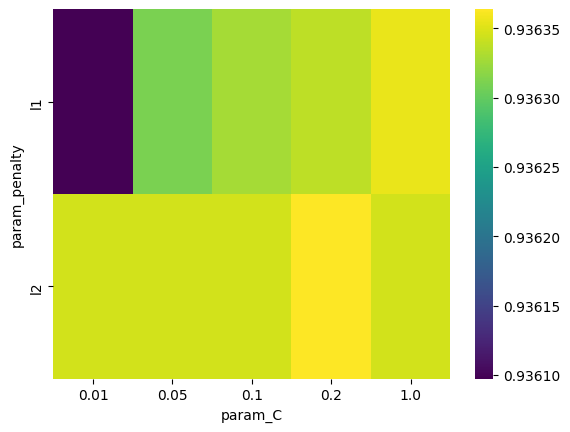

In [ ]:
LR_models = pd.DataFrame(Grid_LR.cv_results_)
res = (LR_models.pivot(index='param_penalty', columns='param_C', values='mean_test_score'))
_ = sns.heatmap(res, cmap='viridis')

### Part 3.2.2: Find Optimal Hyperparameters: KNN

In [ ]:
# Possible hyperparamter options for KNN
# Choose k
parameters = {
    'n_neighbors':[1,3,5,7,9]
}
Grid_KNN = GridSearchCV(KNeighborsClassifier(),parameters, cv=5)
Grid_KNN.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9]})

In [ ]:
# best k
print_grid_search_metrics(Grid_KNN)

Best score: 0.9337682867880547
Best parameters set:
n_neighbors:9


In [ ]:
best_KNN_model = Grid_KNN.best_estimator_

In [ ]:
best_KNN_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
best_KNN_model.score(X_test, y_test)

0.9334666666666667

### Part 3.2.3: Find Optimal Hyperparameters: Random Forest

In [ ]:
# Possible hyperparamter options for Random Forest
# Choose the number of trees
parameters = {
    'n_estimators' : [60,80,100],
    'max_depth': [1,5,10]
}
Grid_RF = GridSearchCV(RandomForestClassifier(),parameters, cv=5)
Grid_RF.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [1, 5, 10],
                         'n_estimators': [60, 80, 100]})

In [ ]:
# best number of tress
print_grid_search_metrics(Grid_RF)

Best score: 0.9372616564686826
Best parameters set:
max_depth:10
n_estimators:100


In [ ]:
# best random forest
best_RF_model = Grid_RF.best_estimator_

In [ ]:
best_RF_model

RandomForestClassifier(max_depth=10)

In [ ]:
best_RF_model.score(X_test, y_test)

0.9367466666666666

## Part 3.3: Model Evaluation - Confusion Matrix (Precision, Recall, Accuracy)

class of interest as positive

TP: correctly labeled real churn

Precision(PPV, positive predictive value): tp / (tp + fp);
Total number of true predictive churn divided by the total number of predictive churn;
High Precision means low fp, not many return users were predicted as churn users.


Recall(sensitivity, hit rate, true positive rate): tp / (tp + fn)
Predict most postive or churn user correctly. High recall means low fn, not many churn users were predicted as return users.

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# calculate accuracy, precision and recall, [[tn, fp],[]]
def cal_evaluation(classifier, cm):
    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]
    accuracy  = (tp + tn) / (tp + fp + fn + tn + 0.0)
    precision = tp / (tp + fp + 0.0)
    recall = tp / (tp + fn + 0.0)
    print (classifier)
    print ("Accuracy is: " + str(accuracy))
    print ("precision is: " + str(precision))
    print ("recall is: " + str(recall))
    print ()

# print out confusion matrices
def draw_confusion_matrices(confusion_matricies):
    class_names = ['Not','Churn']
    for cm in confusion_matrices:
        classifier, cm = cm[0], cm[1]
        cal_evaluation(classifier, cm)

In [ ]:
# Confusion matrix, accuracy, precison and recall for random forest and logistic regression
confusion_matrices = [
    ("Random Forest", confusion_matrix(y_test,best_RF_model.predict(X_test))),
    ("Logistic Regression", confusion_matrix(y_test,best_LR_model.predict(X_test))),
    ("K nearest neighbor", confusion_matrix(y_test, best_KNN_model.predict(X_test)))
]

draw_confusion_matrices(confusion_matrices)

Random Forest
Accuracy is: 0.9367466666666666
precision is: 0.597684515195369
recall is: 0.16473873155165536

Logistic Regression
Accuracy is: 0.9366133333333333
precision is: 0.6371308016877637
recall is: 0.12046270442760271

K nearest neighbor
Accuracy is: 0.9334666666666667
precision is: 0.5065217391304347
recall is: 0.18587953729557238



## Part 3.4: Model Evaluation - ROC & AUC

RandomForestClassifier, KNeighborsClassifier and LogisticRegression have predict_prob() function

### Part 3.4.1: ROC of RF Model

In [ ]:
from sklearn.metrics import roc_curve
from sklearn import metrics

# Use predict_proba to get the probability results of Random Forest
y_pred_rf = best_RF_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)

In [ ]:
best_RF_model.predict_proba(X_test)

array([[0.95398955, 0.04601045],
       [0.76100835, 0.23899165],
       [0.69852599, 0.30147401],
       ...,
       [0.95956066, 0.04043934],
       [0.99238048, 0.00761952],
       [0.98744509, 0.01255491]])

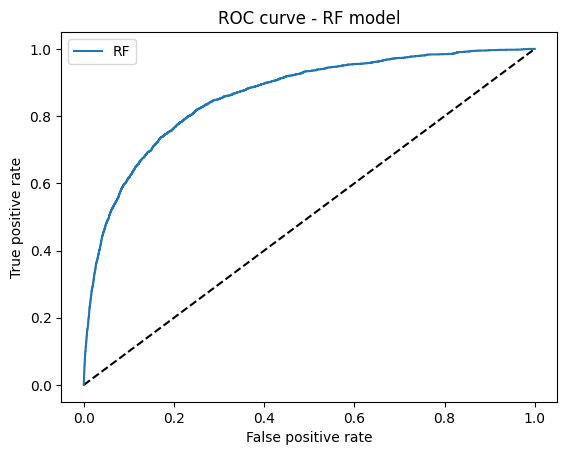

In [ ]:
# ROC curve of Random Forest result
import matplotlib.pyplot as plt
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_rf, tpr_rf, label='RF')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - RF model')
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn import metrics

# AUC score
metrics.auc(fpr_rf,tpr_rf)

np.float64(0.8617333301978648)

### Part 3.4.2: ROC of LR Model

In [ ]:
# Use predict_proba to get the probability results of Logistic Regression
y_pred_lr = best_LR_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresh = roc_curve(y_test, y_pred_lr)

In [ ]:
best_LR_model.predict_proba(X_test)

array([[0.91859704, 0.08140296],
       [0.6517264 , 0.3482736 ],
       [0.80787933, 0.19212067],
       ...,
       [0.9789341 , 0.0210659 ],
       [0.98462195, 0.01537805],
       [0.9794006 , 0.0205994 ]])

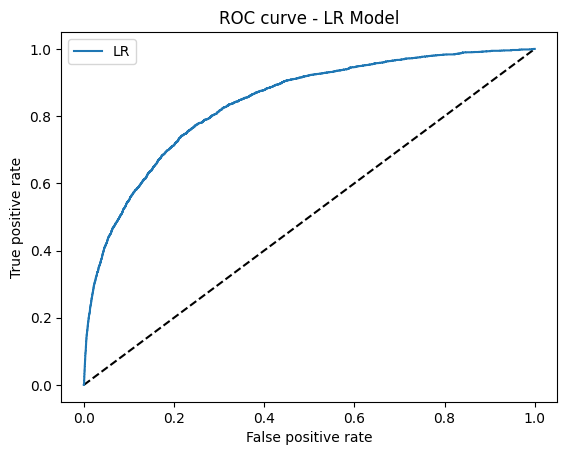

In [ ]:
# ROC Curve
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_lr, tpr_lr, label='LR')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - LR Model')
plt.legend(loc='best')
plt.show()

In [ ]:
# AUC score
metrics.auc(fpr_lr,tpr_lr)

np.float64(0.8397972317695632)

# Part 4: Model Extra Functionality

## Part 4.1: Logistic Regression Model

The corelated features that we are interested in

In [ ]:
X_with_corr = X.copy()

X_with_corr['DebtPerIncome'] = X_with_corr['DebtRatio'] * X_with_corr['MonthlyIncome'] # 构造新特征：每月债务绝对值（DebtRatio * Income）
X_with_corr['CreditPerProperty'] = X_with_corr['NumberOfOpenCreditLinesAndLoans'] / (X_with_corr['NumberRealEstateLoansOrLines'] + 1) # 构造新特征：信用卡数量除以房产贷款数量（避免除以0）

X_with_corr.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,DebtPerIncome,CreditPerProperty
0,0.766127,45,2,0.802982,9120.0,13,0,5,0,2.0,7323.197016,2.166667
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,316.878123,4.000000
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,258.914887,2.000000
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,118.963951,5.000000
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1584.975094,3.500000


In [ ]:
# add L1 regularization to logistic regression
# check the coef for feature selection
scaler = StandardScaler()
X_l1 = scaler.fit_transform(X_with_corr)
LRmodel_l1 = LogisticRegression(penalty="l1", C = 0.04, solver='liblinear')
LRmodel_l1.fit(X_l1, y)

indices = np.argsort(abs(LRmodel_l1.coef_[0]))[::-1]

print ("Logistic Regression (L1) Coefficients")
for ind in range(X_with_corr.shape[1]):
  print ("{0} : {1}".format(X_with_corr.columns[indices[ind]],round(LRmodel_l1.coef_[0][indices[ind]], 4)))

Logistic Regression (L1) Coefficients
RevolvingUtilizationOfUnsecuredLines : 0.789
MonthlyIncome : -0.3069
NumberOfTimes90DaysLate : 0.3054
NumberOfTime30-59DaysPastDueNotWorse : 0.2994
age : -0.236
NumberRealEstateLoansOrLines : 0.171
CreditPerProperty : 0.129
NumberOfTime60-89DaysPastDueNotWorse : 0.0838
NumberOfDependents : 0.0557
DebtRatio : -0.0523
NumberOfOpenCreditLinesAndLoans : 0.0521
DebtPerIncome : 0.0


In [ ]:
# add L2 regularization to logistic regression
# check the coef for feature selection
np.random.seed()
scaler = StandardScaler()
X_l2 = scaler.fit_transform(X_with_corr)
LRmodel_l2 = LogisticRegression(penalty="l2", C = 0.1, solver='liblinear', random_state=42)
LRmodel_l2.fit(X_l2, y)
LRmodel_l2.coef_[0]

indices = np.argsort(abs(LRmodel_l2.coef_[0]))[::-1]

print ("Logistic Regression (L2) Coefficients")
for ind in range(X_with_corr.shape[1]):
  print ("{0} : {1}".format(X_with_corr.columns[indices[ind]],round(LRmodel_l2.coef_[0][indices[ind]], 4)))

Logistic Regression (L2) Coefficients
RevolvingUtilizationOfUnsecuredLines : 0.7902
MonthlyIncome : -0.3566
NumberOfTimes90DaysLate : 0.3069
NumberOfTime30-59DaysPastDueNotWorse : 0.2992
age : -0.2387
NumberRealEstateLoansOrLines : 0.1847
DebtRatio : -0.1658
CreditPerProperty : 0.1388
DebtPerIncome : 0.1118
NumberOfTime60-89DaysPastDueNotWorse : 0.0856
NumberOfDependents : 0.0596
NumberOfOpenCreditLinesAndLoans : 0.0479


## Part 4.2: Random Forest Model - Feature Importance Discussion

In [ ]:
X_RF = X.copy()

X_RF['DebtPerIncome'] = X_RF['DebtRatio'] * X_RF['MonthlyIncome']
X_RF['CreditPerProperty'] = X_RF['NumberOfOpenCreditLinesAndLoans'] / (X_RF['NumberRealEstateLoansOrLines'] + 1)

X_RF.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,DebtPerIncome,CreditPerProperty
0,0.766127,45,2,0.802982,9120.0,13,0,5,0,2.0,7323.197016,2.166667
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,316.878123,4.000000
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,258.914887,2.000000
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,118.963951,5.000000
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1584.975094,3.500000


In [ ]:
# check feature importance of random forest for feature selection
forest = RandomForestClassifier()
forest.fit(X_RF, y)

importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature importance ranking by Random Forest Model:")
for ind in range(X.shape[1]):
  print ("{0} : {1}".format(X_RF.columns[indices[ind]],round(importances[indices[ind]], 4)))

Feature importance ranking by Random Forest Model:
RevolvingUtilizationOfUnsecuredLines : 0.1545
DebtRatio : 0.1306
DebtPerIncome : 0.1293
MonthlyIncome : 0.1123
age : 0.1083
NumberOfTimes90DaysLate : 0.0904
CreditPerProperty : 0.0632
NumberOfOpenCreditLinesAndLoans : 0.0588
NumberOfTime30-59DaysPastDueNotWorse : 0.051
NumberOfTime60-89DaysPastDueNotWorse : 0.0448
